In [1]:
# ResNet CNN for ERA5 Wave Spectra with Residual Learning (No Physics Constraints)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13984\615587787.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [2]:
# Compute baseline reconstruction using directional moments (first harmonic only)
print("Computing baseline spectrum reconstruction...")

def compute_baseline_spectrum(S1D, a1, b1, n_dir=24):
    """Reconstruct 2D spectrum from 1D spectrum and directional moments"""
    # Use exact same directional grid as in preprocessing
    direction_deg = 7.5 + 15 * np.arange(n_dir)  # ERA5 directions: 7.5°, 22.5°, ..., 352.5°
    theta = np.deg2rad(direction_deg)
    ddir = np.deg2rad(15.0)  # 15° spacing
    
    # Initialize output
    S_baseline = np.zeros((S1D.shape[0], S1D.shape[1], n_dir))
    
    for i in range(S1D.shape[0]):
        for j in range(S1D.shape[1]):
            if S1D[i, j] > 1e-15:  # Only process non-zero frequencies
                # Correct first-harmonic directional distribution formula
                D = (1/(2*np.pi)) * (1 + 2*a1[i, j] * np.cos(theta) + 2*b1[i, j] * np.sin(theta))
                
                # Ensure non-negative
                D = np.maximum(D, 0)
                
                # Normalize using discrete integration
                integral = np.sum(D) * ddir
                if integral > 1e-10:
                    D = D / integral
                else:
                    D = np.ones(n_dir) / n_dir  # Uniform if coefficients invalid
                
                # Multiply by 1D spectrum
                S_baseline[i, j, :] = S1D[i, j] * D
    
    return S_baseline



Computing baseline spectrum reconstruction...


In [ ]:
# Compute baseline reconstruction
S_baseline = compute_baseline_spectrum(S1D, a1, b1)

# Compute residuals (what the ResNet CNN will learn)
residuals = S2D - S_baseline

print(f"Baseline shape: {S_baseline.shape}")
print(f"Residuals shape: {residuals.shape}")
print(f"Baseline energy: {np.mean(np.sum(S_baseline, axis=(1,2))):.4f}")
print(f"Original energy: {np.mean(np.sum(S2D, axis=(1,2))):.4f}")
print(f"Residual energy: {np.mean(np.sum(residuals, axis=(1,2))):.4f}")

# Check for NaN in computed arrays
print(f"NaN in baseline: {np.isnan(S_baseline).sum()}")
print(f"NaN in residuals: {np.isnan(residuals).sum()}")

In [4]:
# Prepare inputs for ResNet CNN model
print("Preparing inputs for ResNet CNN model...")

# Create model inputs by stacking ALL features into channels
# Input: (batch, channels=5, freq=30) where channels = [S1D, a1, b1, a2, b2]
batch_size, n_freq, n_dir = S2D.shape

# Stack all features as channels for CNN input
inputs = np.stack([
    S1D,  # Channel 0: 1D spectrum
    a1,   # Channel 1: First harmonic moment a1
    b1,   # Channel 2: First harmonic moment b1
    a2,   # Channel 3: Second harmonic moment a2 - NEW
    b2    # Channel 4: Second harmonic moment b2 - NEW
], axis=1)  # Shape: (batch_size, 5, 30)

# Target is the residual (what to add to baseline)
targets = residuals  # Shape: (batch_size, 30, 24)

print(f"Input shape: {inputs.shape} (batch, channels=5, freq=30)")
print(f"Target shape: {targets.shape} (batch, freq=30, dir=24)")
print(f"Input channels: S1D, a1, b1, a2, b2")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=(1,2))
    target_mask = ~np.isnan(targets).any(axis=(1,2))
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    S_baseline = S_baseline[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for ResNet CNN model...
Input shape: (9504, 5, 30) (batch, channels=5, freq=30)
Target shape: (9504, 30, 24) (batch, freq=30, dir=24)
Input channels: S1D, a1, b1, a2, b2
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [-4.785140, 14.124423]
Input mean: -0.121308, std: 0.506509
Target mean: 0.000000, std: 0.117018


In [5]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs channel-wise for CNN
input_mean = inputs.mean(axis=(0, 2), keepdims=True)  # Mean over batch and frequency
input_std = inputs.std(axis=(0, 2), keepdims=True) + 1e-8  # Std over batch and frequency
inputs_norm = (inputs - input_mean) / input_std


# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/resnet_res_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/resnet_res_normalization.npz")

# For targets, use raw residuals without scaling
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization per channel:")
for i, name in enumerate(['S1D', 'a1', 'b1', 'a2', 'b2']):
    print(f"  {name}: Mean={input_mean[0, i, 0]:.6f}, Std={input_std[0, i, 0]:.6f}")

print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Also split original data for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]
S_baseline_train = S_baseline[train_idx]
S_baseline_val = S_baseline[val_idx]
S_baseline_test = S_baseline[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/resnet_res_normalization.npz
Input normalization per channel:
  S1D: Mean=0.162311, Std=0.477422
  a1: Mean=0.115850, Std=0.423460
  b1: Mean=-0.516164, Std=0.484411
  a2: Mean=-0.265445, Std=0.396450
  b2: Mean=-0.103093, Std=0.412283
Target scaling factor: 1.000000
Normalized input range: [-2.614872, 46.798307]
Normalized target range: [-4.785140, 14.124423]
Data splits:
Train: 6652 samples
Val: 1425 samples
Test: 1427 samples
Using device: cpu


In [3]:
# Define ResNet CNN architecture for residual learning
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dropout=0.1):
        super(ResidualBlock1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        
        # Skip connection
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.skip = nn.Identity()
    
    def forward(self, x):
        residual = self.skip(x)
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        
        out += residual
        return F.relu(out)

class ResNetCNN(nn.Module):
    def __init__(self, input_channels=5, n_freq=30, n_dir=24, base_channels=64):
        super(ResNetCNN, self).__init__()
        self.n_freq = n_freq
        self.n_dir = n_dir
        
        # Initial convolution
        self.initial_conv = nn.Sequential(
            nn.Conv1d(input_channels, base_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        # ResNet blocks
        self.layer1 = self._make_layer(base_channels, base_channels, 2)
        self.layer2 = self._make_layer(base_channels, base_channels*2, 2)
        self.layer3 = self._make_layer(base_channels*2, base_channels*4, 2)
        
        # Decoder layers to upsample back to target dimensions
        self.decoder = nn.Sequential(
            nn.Conv1d(base_channels*4, base_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm1d(base_channels*2),
            nn.ReLU(inplace=True),
            nn.Conv1d(base_channels*2, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        # Final layers to get directional output
        self.final_conv = nn.Sequential(
            nn.Conv1d(base_channels, base_channels//2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(base_channels//2, n_dir, kernel_size=1)  # Output 24 directions per frequency
        )
        
        # Initialize weights
        self._init_weights()
    
    def _make_layer(self, in_channels, out_channels, num_blocks):
        layers = []
        layers.append(ResidualBlock1D(in_channels, out_channels))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # x shape: (batch, 5, 30)
        
        # Initial convolution
        x = self.initial_conv(x)  # (batch, base_channels, 30)
        
        # ResNet layers
        x = self.layer1(x)        # (batch, base_channels, 30)
        x = self.layer2(x)        # (batch, base_channels*2, 30)
        x = self.layer3(x)        # (batch, base_channels*4, 30)
        
        # Decode back to target size
        x = self.decoder(x)       # (batch, base_channels, 30)
        
        # Final convolution to get directional output
        x = self.final_conv(x)    # (batch, 24, 30)
        
        # Transpose to get (batch, freq, dir)
        x = x.transpose(1, 2)     # (batch, 30, 24)
        
        return x



In [ ]:
# Create model
model = ResNetCNN(input_channels=5, n_freq=n_freq, n_dir=n_dir).to(device)

print(f"ResNet CNN model created:")
print(f"Input channels: 5 (S1D + a1 + b1 + a2 + b2)")
print(f"Output shape: ({n_freq}, {n_dir}) - residuals")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_batch = X_train_t[:4]  
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("ResNet CNN architecture defined successfully")

In [4]:
# Define reconstruction and loss functions
def reconstruct_2d_spectrum(residuals, baseline_tensor, batch_size):
    """Reconstruct 2D spectrum from predicted residuals and baseline"""
    # Add residuals to baseline
    reconstructed = baseline_tensor + residuals
    
    # Enforce non-negativity
    reconstructed = torch.clamp(reconstructed, min=0.0)
    
    return reconstructed



In [ ]:
# Test reconstruction function
print("Testing reconstruction function...")
with torch.no_grad():
    # Create test tensors
    test_residuals = model(X_train_t[:4])
    test_baseline = torch.FloatTensor(S_baseline_train[:4]).to(device)
    test_target = torch.FloatTensor(S2D_train[:4]).to(device)
    
    # Reconstruct spectrum
    test_recon = reconstruct_2d_spectrum(test_residuals, test_baseline, 4)
    
    # Compute MSE loss
    mse_loss = torch.mean((test_recon - test_target)**2)
    
    print(f"Test reconstruction shape: {test_recon.shape}")
    print(f"Test MSE loss: {mse_loss.item():.6f}")
    print(f"Reconstruction range: [{test_recon.min().item():.6f}, {test_recon.max().item():.6f}]")
    
    # Check for NaN in loss
    if torch.isnan(mse_loss):
        print("WARNING: NaN in loss function!")
    else:
        print("✓ Reconstruction function working correctly")

print("Functions defined successfully")

In [8]:
# Training setup
print("Setting up training...")

# Prepare baseline arrays as tensors for training
S_baseline_train_t = torch.FloatTensor(S_baseline_train).to(device)
S_baseline_val_t = torch.FloatTensor(S_baseline_val).to(device)
S2D_train_t = torch.FloatTensor(S2D_train).to(device)
S2D_val_t = torch.FloatTensor(S2D_val).to(device)

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate for ResNet
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization

# Create data loaders
train_dataset = TensorDataset(X_train_t, y_train_t, S_baseline_train_t, S2D_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t, S_baseline_val_t, S2D_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

# MSE loss function (no physics constraints)
criterion = nn.MSELoss()

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss function: MSE only (no physics constraints)")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Ready to start ResNet CNN training")

Setting up training...
Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
  Loss function: MSE only (no physics constraints)
Ready to start ResNet CNN training


In [9]:
# Training loop
model_path = "models/resnet_res.pth"

print("Starting ResNet CNN training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass - predict residuals
        residuals_pred = model(batch_x)
        
        # Reconstruct 2D spectrum
        reconstructed = reconstruct_2d_spectrum(
            residuals_pred, batch_baseline, batch_x.shape[0]
        )
        
        # Compute MSE loss on reconstructed spectrum
        loss = criterion(reconstructed, batch_target_2d)
        
        # Check for NaN 
        if torch.isnan(loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Residuals range: [{residuals_pred.min().item():.6f}, {residuals_pred.max().item():.6f}]")
            print(f"  Reconstructed range: [{reconstructed.min().item():.6f}, {reconstructed.max().item():.6f}]")
            break
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(val_loader):
            # Forward pass
            residuals_pred = model(batch_x)
            
            # Reconstruct 2D spectrum
            reconstructed = reconstruct_2d_spectrum(
                residuals_pred, batch_baseline, batch_x.shape[0]
            )
            
            # Compute MSE loss
            loss = criterion(reconstructed, batch_target_2d)
            
            if not torch.isnan(loss):
                epoch_val_loss += loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best ResNet residual model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 50)

print("ResNet CNN training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting ResNet CNN training...
  Batch 50/208, Loss: 0.092851
  Batch 100/208, Loss: 0.081594
  Batch 150/208, Loss: 0.017558
  Batch 200/208, Loss: 0.012629
Epoch 1/50
  Train Loss: 0.096176
  Val Loss: 0.014302
  Learning Rate: 1.00e-04
  ✓ New best ResNet residual model saved (val_loss: 0.014302)
--------------------------------------------------
  Batch 50/208, Loss: 0.007463
  Batch 100/208, Loss: 0.006999
  Batch 150/208, Loss: 0.005038
  Batch 200/208, Loss: 0.007929
Epoch 2/50
  Train Loss: 0.014590
  Val Loss: 0.011925
  Learning Rate: 1.00e-04
  ✓ New best ResNet residual model saved (val_loss: 0.011925)
--------------------------------------------------
  Batch 50/208, Loss: 0.045337
  Batch 100/208, Loss: 0.002836
  Batch 150/208, Loss: 0.014903
  Batch 200/208, Loss: 0.007983
Epoch 3/50
  Train Loss: 0.013428
  Val Loss: 0.011157
  Learning Rate: 1.00e-04
  ✓ New best ResNet residual model saved (val_loss: 0.011157)
--------------------------------------------------
  Bat

In [11]:
# Model evaluation and R-squared analysis
print("Evaluating ResNet CNN model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare test data
S_baseline_test_t = torch.FloatTensor(S_baseline_test).to(device)
S2D_test_t = torch.FloatTensor(S2D_test).to(device)

# Make predictions on test set
with torch.no_grad():
    test_residuals = model(X_test_t)
    test_reconstructed = reconstruct_2d_spectrum(
        test_residuals, S_baseline_test_t, len(X_test_t)
    )

# Convert back to numpy for evaluation
test_reconstructed_np = test_reconstructed.cpu().numpy()
test_target_np = S2D_test

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# Baseline error vs ResNet CNN error
baseline_error = compute_relative_error(S_baseline_test, S2D_test)
resnet_error = compute_relative_error(test_reconstructed_np, test_target_np)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

# L2 errors for baseline
norm_true = np.linalg.norm(test_target_np.reshape(n_time, -1), axis=1)
norm_diff_baseline = np.linalg.norm((S_baseline_test - test_target_np).reshape(n_time, -1), axis=1)
relative_l2_error_baseline = norm_diff_baseline / (norm_true + epsilon_l2)
l2_baseline_error = np.mean(relative_l2_error_baseline)

# L2 errors for ResNet CNN
norm_diff_resnet = np.linalg.norm((test_reconstructed_np - test_target_np).reshape(n_time, -1), axis=1)
relative_l2_error_resnet = norm_diff_resnet / (norm_true + epsilon_l2)
l2_resnet_error = np.mean(relative_l2_error_resnet)

# R-squared calculation
print("Computing R-squared values...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_baseline_flat = S_baseline_test.flatten()
y_pred_resnet_flat = test_reconstructed_np.flatten()

# Calculate R-squared for baseline model
ss_res_baseline = np.sum((y_true_flat - y_pred_baseline_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_baseline = 1 - (ss_res_baseline / ss_tot)

# Calculate R-squared for ResNet CNN model
ss_res_resnet = np.sum((y_true_flat - y_pred_resnet_flat) ** 2)
r2_resnet = 1 - (ss_res_resnet / ss_tot)

print("\n" + "="*60)
print("RESNET CNN WITH RESIDUAL LEARNING EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"Baseline error (moments only):     {baseline_error:.6f}")
print(f"ResNet CNN error (with residuals): {resnet_error:.6f}")
print(f"Improvement factor:                {baseline_error/resnet_error:.4f}x")
print(f"Relative improvement:              {(baseline_error-resnet_error)/baseline_error*100:.2f}%")

print("\nL2 ERROR (RELATIVE) ANALYSIS:")
print(f"Baseline L2 error:     {l2_baseline_error:.6f}")
print(f"ResNet CNN L2 error:   {l2_resnet_error:.6f}")
print(f"L2 Improvement:        {l2_baseline_error - l2_resnet_error:.6f}")
print(f"L2 Reduction (%):      {(l2_baseline_error - l2_resnet_error)/l2_baseline_error*100:.2f}%")

print("\nR-SQUARED ANALYSIS:")
print(f"Baseline R²:           {r2_baseline:.6f}")
print(f"ResNet CNN R²:         {r2_resnet:.6f}")
print(f"R² Improvement:        {r2_resnet - r2_baseline:.6f}")
print(f"R² Improvement (%):    {(r2_resnet - r2_baseline)/abs(r2_baseline)*100:.2f}%")

# Correlation coefficients  
corr_baseline = np.corrcoef(y_true_flat, y_pred_baseline_flat)[0, 1]
corr_resnet = np.corrcoef(y_true_flat, y_pred_resnet_flat)[0, 1]

print(f"\nPearson correlations:")
print(f"  Baseline: {corr_baseline:.6f}")
print(f"  ResNet CNN: {corr_resnet:.6f}")

# Energy conservation check
energy_conservation = np.abs(
    np.mean(np.sum(test_reconstructed_np, axis=(1,2))) - np.mean(np.sum(test_target_np, axis=(1,2)))
) / np.mean(np.sum(test_target_np, axis=(1,2)))

print(f"\nAdditional statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean ResNet energy:                {np.mean(np.sum(test_reconstructed_np, axis=(1,2))):.6f}")
print(f"Mean baseline energy:              {np.mean(np.sum(S_baseline_test, axis=(1,2))):.6f}")
print(f"Energy conservation error:         {energy_conservation:.6f}")

print(f"\nRESNET CNN MODEL SUMMARY:")
print(f"  Input: 5 channels (S1D + a1 + b1 + a2 + b2) → (batch, 5, 30)")
print(f"  Architecture: ResNet CNN with residual blocks")
print(f"  Learning: Residual corrections to baseline spectrum")
print(f"  Loss: MSE only (no physics constraints)")
print(f"  Final Performance:")
print(f"    - Weighted Error: {resnet_error:.6f}")
print(f"    - L2 Error (Relative): {l2_resnet_error:.6f}")
print(f"    - R²: {r2_resnet:.6f} ({r2_resnet*100:.2f}% variance explained)")
print(f"    - Improvement over baseline: {baseline_error/resnet_error:.2f}x")

print("\n✓ ResNet CNN with residual learning evaluation completed!")
print("="*60)

Evaluating ResNet CNN model...
Computing R-squared values...

RESNET CNN WITH RESIDUAL LEARNING EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
Baseline error (moments only):     0.667998
ResNet CNN error (with residuals): 0.354411
Improvement factor:                1.8848x
Relative improvement:              46.94%

L2 ERROR (RELATIVE) ANALYSIS:
Baseline L2 error:     0.651692
ResNet CNN L2 error:   0.329840
L2 Improvement:        0.321852
L2 Reduction (%):      49.39%

R-SQUARED ANALYSIS:
Baseline R²:           0.524034
ResNet CNN R²:         0.945864
R² Improvement:        0.421830
R² Improvement (%):    80.50%

Pearson correlations:
  Baseline: 0.739306
  ResNet CNN: 0.972747

Additional statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean ResNet energy:                25.821260
Mean baseline energy:              27.796832
Energy conservation error:         0.071072

RESNET CNN MODEL SUMMARY:
  Input: 5 channels (S1D + a1 + b1

# 🌊 Evaluation on Independent Dataset

Evaluate the trained ResNet CNN with residual learning on completely separate evaluation data.

In [5]:
# Load ERA5 evaluation data and normalization parameters
print("Loading ERA5 evaluation data for final assessment...")
model_path = "models/resnet_res.pth"
eval_data_path = "eval_data\\processed_0\\era5_wave_eval.npz"
eval_data = np.load(eval_data_path)

print(f"ERA5 evaluation data loaded:")
print(f"  X shape: {eval_data['X'].shape}")
print(f"  y shape: {eval_data['y'].shape}")

# Load normalization parameters
norm_params = np.load("models/resnet_res_normalization.npz")
eval_input_mean = norm_params['input_mean']
eval_input_std = norm_params['input_std']

print("Normalization parameters loaded for consistent preprocessing")

# Extract evaluation set components
eval_X = eval_data['X']  # Shape: (samples, 5, 30) - S1D, a1, b1, a2, b2
eval_y = eval_data['y']  # Shape: (samples, 30, 24) - 2D spectra

print(f"ERA5 evaluation set: {eval_X.shape[0]} samples")
print(f"Input channels: S1D, a1, b1, a2, b2")

Loading ERA5 evaluation data for final assessment...
ERA5 evaluation data loaded:
  X shape: (1416, 5, 30)
  y shape: (1416, 30, 24)
Normalization parameters loaded for consistent preprocessing
ERA5 evaluation set: 1416 samples
Input channels: S1D, a1, b1, a2, b2


In [6]:
# Preprocess ERA5 evaluation data using existing functions  
print("Preprocessing ERA5 evaluation data...")

# Extract components from evaluation data
eval_S1D = eval_X[:, 0, :]  # 1D spectra: (samples, 30)
eval_a1 = eval_X[:, 1, :]   # Directional moment a1: (samples, 30)
eval_b1 = eval_X[:, 2, :]   # Directional moment b1: (samples, 30)
eval_a2 = eval_X[:, 3, :]   # Directional moment a2: (samples, 30)
eval_b2 = eval_X[:, 4, :]   # Directional moment b2: (samples, 30)

# Compute baseline reconstruction using existing function
eval_baseline = compute_baseline_spectrum(eval_S1D, eval_a1, eval_b1)

print(f"ERA5 evaluation baseline computed:")
print(f"  Baseline shape: {eval_baseline.shape}")
print(f"  Baseline range: [{eval_baseline.min():.6f}, {eval_baseline.max():.6f}]")

# Normalize inputs using saved parameters
eval_X_norm = (eval_X - eval_input_mean) / eval_input_std

print(f"Normalized evaluation inputs:")
print(f"  Range: [{eval_X_norm.min():.6f}, {eval_X_norm.max():.6f}]")
print(f"  Shape: {eval_X_norm.shape}")

# Convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_X_tensor = torch.FloatTensor(eval_X_norm).to(device)
eval_y_tensor = torch.FloatTensor(eval_y).to(device)
eval_baseline_tensor = torch.FloatTensor(eval_baseline).to(device)

print(f"ERA5 evaluation data ready for model inference")
print(f"  Device: {device}")
print(f"  Input tensor shape: {eval_X_tensor.shape}")
print(f"  Target tensor shape: {eval_y_tensor.shape}")
print(f"  Baseline tensor shape: {eval_baseline_tensor.shape}")

Preprocessing ERA5 evaluation data...
ERA5 evaluation baseline computed:
  Baseline shape: (1416, 30, 24)
  Baseline range: [0.000000, 30.589802]
Normalized evaluation inputs:
  Range: [-2.614872, 164.956481]
  Shape: (1416, 5, 30)
ERA5 evaluation data ready for model inference
  Device: cpu
  Input tensor shape: torch.Size([1416, 5, 30])
  Target tensor shape: torch.Size([1416, 30, 24])
  Baseline tensor shape: torch.Size([1416, 30, 24])


In [7]:
# Evaluate model on ERA5 evaluation set using saved model
print("Evaluating ResNet CNN with residual learning on ERA5 data...")

# Get dimensions from eval data
n_freq, n_dir = eval_y.shape[1], eval_y.shape[2]  # (30, 24)

# Create fresh model instance for evaluation  
model = ResNetCNN(input_channels=5, n_freq=n_freq, n_dir=n_dir).to(device)

# Load best trained model
model.load_state_dict(torch.load("models/resnet_res.pth"))
model.eval()

# Perform inference on evaluation set
with torch.no_grad():
    # Predict residuals
    eval_residuals = model(eval_X_tensor)
    
    # Reconstruct full 2D spectra using existing function
    eval_pred = reconstruct_2d_spectrum(eval_residuals, eval_baseline_tensor, len(eval_X_tensor))
    
    print(f"ERA5 evaluation complete:")
    print(f"  Residuals shape: {eval_residuals.shape}")
    print(f"  Predictions shape: {eval_pred.shape}")
    print(f"  Prediction range: [{eval_pred.min().item():.6f}, {eval_pred.max().item():.6f}]")
    
    # Convert to numpy for analysis
    eval_pred_np = eval_pred.cpu().numpy()
    eval_target_np = eval_y_tensor.cpu().numpy()
    eval_baseline_np = eval_baseline_tensor.cpu().numpy()

# Compute evaluation metrics
eval_mse = np.mean((eval_pred_np - eval_target_np) ** 2)
eval_mae = np.mean(np.abs(eval_pred_np - eval_target_np))

# Compute R-squared for ERA5 evaluation
eval_y_flat = eval_target_np.flatten()
eval_pred_flat = eval_pred_np.flatten()
eval_ss_tot = np.sum((eval_y_flat - np.mean(eval_y_flat)) ** 2)
eval_ss_res = np.sum((eval_y_flat - eval_pred_flat) ** 2)
eval_r2 = 1 - (eval_ss_res / eval_ss_tot)

# Compare with baseline (MEM method)
eval_baseline_flat = eval_baseline_np.flatten()
eval_baseline_ss_res = np.sum((eval_y_flat - eval_baseline_flat) ** 2)
eval_baseline_r2 = 1 - (eval_baseline_ss_res / eval_ss_tot)

print(f"ERA5 evaluation metrics:")
print(f"  MSE: {eval_mse:.6f}")
print(f"  MAE: {eval_mae:.6f}")  
print(f"  R²: {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")

print(f"ERA5 baseline comparison:")
print(f"  Baseline R²: {eval_baseline_r2:.6f} ({eval_baseline_r2*100:.2f}% variance explained)")
print(f"  R² improvement: {eval_r2 - eval_baseline_r2:.6f}")
print(f"  Improvement factor: {(eval_r2 - eval_baseline_r2)/abs(eval_baseline_r2)*100:.2f}%")

print("✓ ERA5 evaluation completed successfully")

Evaluating ResNet CNN with residual learning on ERA5 data...
ERA5 evaluation complete:
  Residuals shape: torch.Size([1416, 30, 24])
  Predictions shape: torch.Size([1416, 30, 24])
  Prediction range: [0.000000, 37.452801]
ERA5 evaluation metrics:
  MSE: 0.756218
  MAE: 0.118291
  R²: 0.597408 (59.74% variance explained)
ERA5 baseline comparison:
  Baseline R²: 0.551659 (55.17% variance explained)
  R² improvement: 0.045749
  Improvement factor: 8.29%
✓ ERA5 evaluation completed successfully


Creating visualization of ResNet CNN with residual learning results...


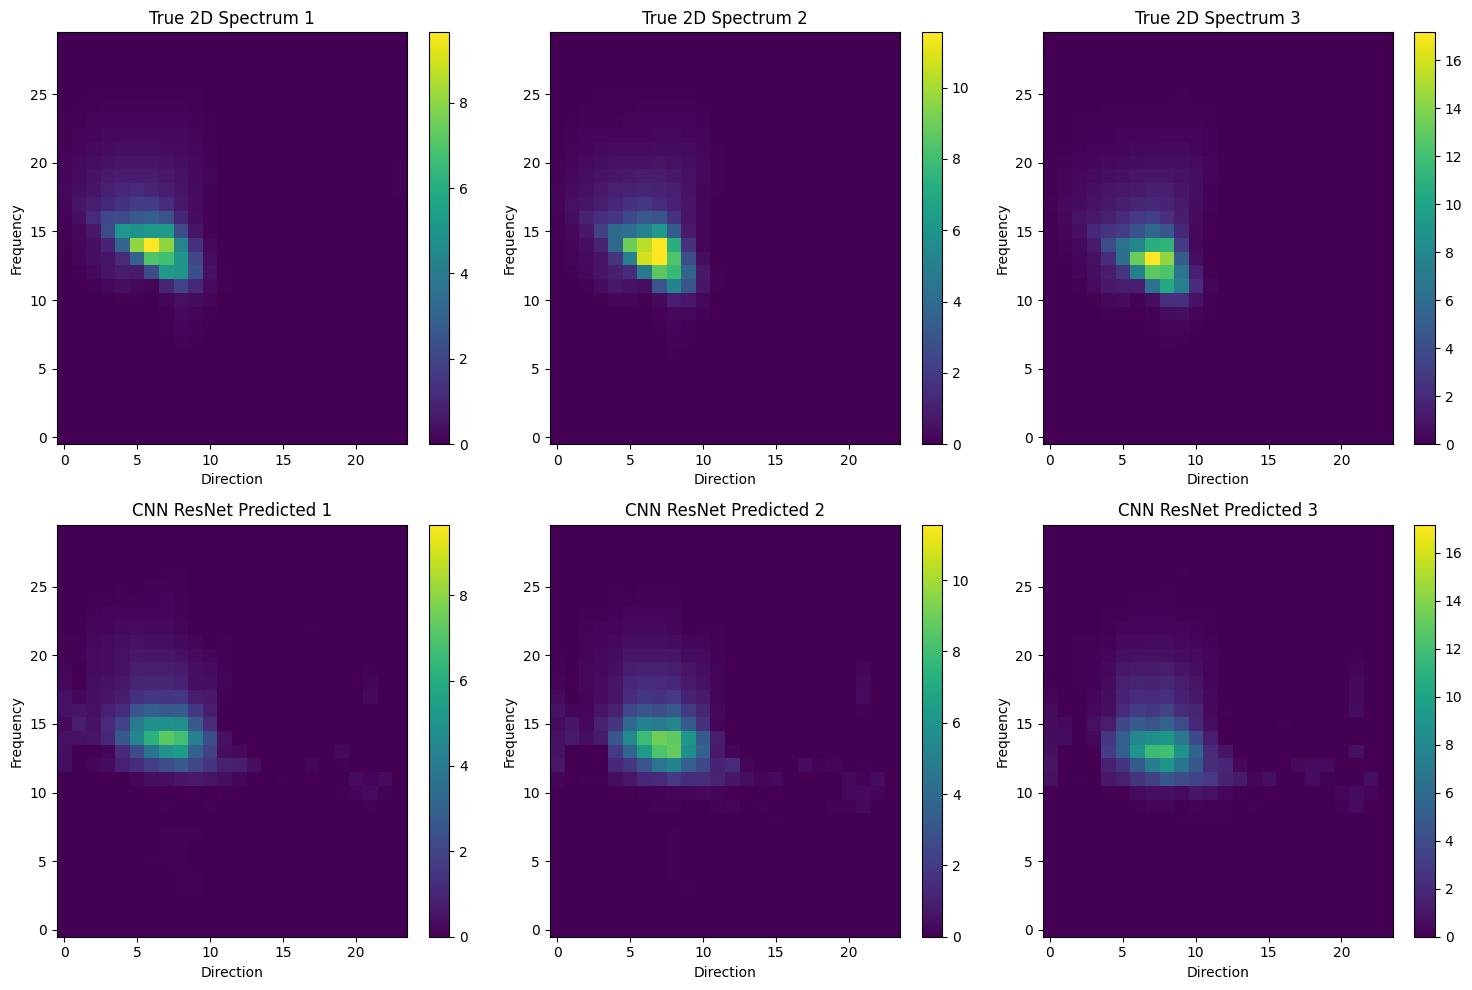

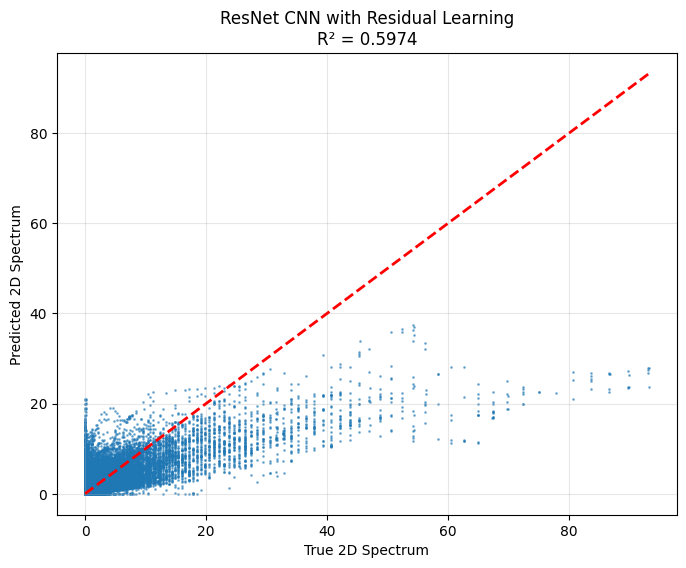

ResNet CNN with residual learning evaluation completed!


In [8]:
# Visualize ERA5 evaluation results  
import matplotlib.pyplot as plt

print("Creating visualization of ResNet CNN with residual learning results...")

# Select 3 representative samples for visualization
sample_indices = [0, 1, 2]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot heatmaps for 3 timestamps
for i, idx in enumerate(sample_indices):
    sample_target = eval_target_np[idx]
    sample_pred = eval_pred_np[idx]
    
    # Determine common color scale for this timestamp
    vmax = max(sample_target.max(), sample_pred.max())
    
    # Top row: True spectra
    im1 = axes[0,i].imshow(sample_target, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[0,i].set_title(f'True 2D Spectrum {idx+1}')
    axes[0,i].set_xlabel('Direction')
    axes[0,i].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[0,i])
    
    # Bottom row: Predicted spectra
    im2 = axes[1,i].imshow(sample_pred, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[1,i].set_title(f'CNN ResNet Predicted {idx+1}')
    axes[1,i].set_xlabel('Direction')
    axes[1,i].set_ylabel('Frequency')
    plt.colorbar(im2, ax=axes[1,i])

plt.tight_layout()
plt.show()

# R² scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(eval_target_np.flatten(), eval_pred_np.flatten(), alpha=0.5, s=1)
plt.plot([eval_target_np.min(), eval_target_np.max()], [eval_target_np.min(), eval_target_np.max()], 'r--', lw=2)
plt.xlabel('True 2D Spectrum')
plt.ylabel('Predicted 2D Spectrum')
plt.title(f'ResNet CNN with Residual Learning\nR² = {eval_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print("="*70)
print("ResNet CNN with residual learning evaluation completed!")
print("="*70)